## Modeling the Shakura–Sunyaev Accretion Disk Spectrum and Ionizing Luminosities


# Part I — Modeling the Shakura–Sunyaev Disk Emission

In this first part of the program, I model the emission from a Shakura–Sunyaev accretion disk, assuming that each disk annulus emits as a black body.

The procedure is the following:

1. Starting from a given black hole mass, I compute the Eddington luminosity, the disk luminosity, and the corresponding mass accretion rate. I also fix the inner and outer disk radii.

2. I define a radial grid between \(R_\mathrm{in}\) and \(R_\mathrm{out}\), and a frequency grid between \(10^{13}\) and \(10^{17}\,\mathrm{Hz}\).

3. I compute the disk temperature at each radius as a function of \(M_\mathrm{BH}\), \(\dot{M}\), and \(R\).

4. Using Planck’s black-body law, I construct the matrix \(B_\nu(\nu, R)\), evaluated for all frequencies and all radii.

5. I compute the integral of \(R B_\nu(\nu,R)\) over radius, from \(R_\mathrm{in}\) to \(R_\mathrm{out}\), using NumPy’s trapezoidal integration method. This gives the monochromatic luminosity \(L_\nu(M_\mathrm{BH},\dot{M};\nu)\), i.e. the total disk luminosity at each frequency. The integral is multiplied by \(4\pi^2\).

6. I plot \(\nu L_\nu\) as a function of frequency in log-log scale. In the y-axis quantity, I actually use \(\nu L_\nu 2\cos\theta\), where \(\theta\) is the angle between the normal to the flat disk surface and the line of sight. This correction accounts for the fact that, if the blazar disk is inclined with respect to the observer, less light is received. Since \(\theta\) is only a few degrees, the correction is small.

7. I test the reliability of the disk-emission model through four checks:

   - First test: I compute \(\nu_\mathrm{peak}L_{\nu,\mathrm{peak}}\), which should be approximately \(0.5 L_\mathrm{disk}\).

   - Second test: I integrate \(L_\nu\) over all frequencies. The result should be close to \(L_\mathrm{disk}\). It is important to extend the frequency range up to \(10^{17}\,\mathrm{Hz}\), rather than stopping at \(10^{16}\,\mathrm{Hz}\), in order to include the high-frequency tail.

   - Third test: I vary \(M_\mathrm{BH}\) while keeping \(\dot{M}\) fixed. I expect the emission peak to shift toward lower frequencies as \(M_\mathrm{BH}\) increases.

   - Fourth test: I vary \(\dot{M}\), equivalently by setting \(L_\mathrm{disk}\) equal to different fractions of \(L_\mathrm{Edd}\) — 1%, 10%, and 30% — while keeping \(M_\mathrm{BH}\) fixed. I expect the peak to move upward and toward higher frequencies as the luminosity factor increases.

At the end of the third and fourth tests, I also repeat the first test for the different plotted curves.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters and constants for the accretion disk: c, G, h, kB, sigma, Msun

c = 2.99792458e10          # cm/s
G = 6.67430e-8             # cgs units = cm^3 g^-1 s^-2
h = 6.62607015e-27         # erg*s
kB = 1.380649e-16          # erg/K, Boltzmann constant
sigma = 5.670374419e-5     # erg cm^-2 s^-1 K^-4, Stefan-Boltzmann constant
Msun = 1.98847e33          # g

MBH = 1e8 * Msun
eta = 0.083                # Mass-to-energy conversion efficiency.
                           # A value of 0.083 works better than 0.1.
                           # A value close to 0.08 corresponds to a non-rotating disk,
                           # although in reality the disk would rotate.

Ledd = 1.3e38 * (MBH / Msun)  # erg/s
Ldisk = 0.1 * Ledd            # erg/s
Mdot = Ldisk / (eta * c**2)   # g/s, mass accretion rate

Rs = 2 * G * MBH / c**2       # cm
Rin = 3 * Rs                  # Inner disk radius
Rout = 3000 * Rs              # Outer disk radius

In [3]:
# Radial grid
Nr = 2000  # Number of radial points
R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)  # cm

# Temperature as a function of MBH, Mdot, and R
f = 1.0 - np.sqrt(Rin / R)
f = np.clip(f, 0.0, None)  # Avoid negative values for R < Rin
T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25  # K

# Frequency grid
Nnu = 400  # Number of frequency points
nu = np.logspace(13, 17, Nnu)  # Hz
# It is better to extend the frequency range up to 10^17 Hz,
# especially when computing the ionizing luminosities of the lines

In [4]:
# Initialize the Bnu matrix with shape (Nnu, Nr):
# rows = frequencies, columns = radii/temperatures
Bnu = np.zeros((Nnu, Nr))

# Compute B_nu(nu, T) for each frequency and temperature
for j in range(Nr):  # Loop over radii
    x = h * nu / (kB * T[j])  # Array with shape (Nnu,), containing x for each frequency at that radius
    x = np.clip(x, 1e-12, 700.0)  # Avoid overflow for large x values
    Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

In [5]:
# Compute L(nu) by integrating over R
integrand = R[None, :] * Bnu
# Note: R[None, :] is needed because R has shape (Nr,) and Bnu has shape (Nnu, Nr).
# With None, R becomes shape (1, Nr), so the integrand has shape (Nnu, Nr).

I_nu = np.trapezoid(integrand, R, axis=1)
# Integral over R for each frequency. The result is an array with shape (Nnu,).
Lnu = 4 * np.pi**2 * I_nu
# L(nu) for each frequency, array with shape (Nnu,)
nuLnu = nu * Lnu

theta = 3.0 * np.pi / 180.0
# Viewing angle of the disk with respect to the disk normal, in radians: 3 degrees.

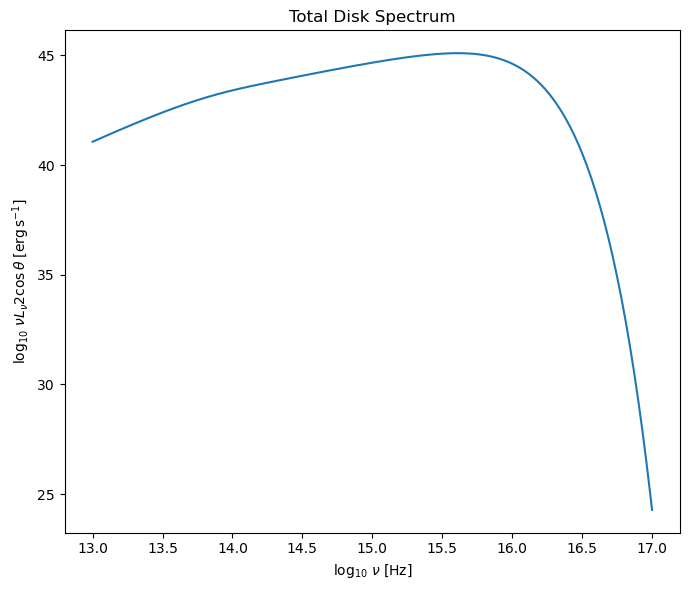

In [6]:
# Plot of the total disk spectrum in the form nu*L(nu) vs nu
plt.figure(figsize=(7, 6))
plt.plot(
    np.log10(nu),
    np.log10(nuLnu * 2 * np.cos(theta)),
    label=r'$L_\mathrm{disk} = 0.1 L_\mathrm{Edd}$'
)

plt.xlabel(r'$\log_{10}\,\nu \;[\mathrm{Hz}]$')
plt.ylabel(r'$\log_{10}\,\nu L_\nu 2\cos\theta \;[\mathrm{erg\,s^{-1}}]$')
plt.title('Total Disk Spectrum')
plt.tight_layout()
plt.show()

FIRST TEST:  
I compute nu_peak*L(nu_peak) and compare it with 0.5*Ldisk.  
The peak value indicates where most of the energy is emitted.  
Since Ldisk is the total emitted power, if the peak is close to 0.5*Ldisk,this means that most of the energy is emitted around that frequency, the peak is therefore a good indicator of the total disk power.  
If the peak is much lower than 0.5*Ldisk, it means that most of the energy is emitted at lower frequencies, so the peak does not represent the total disk power well.

In [7]:
i_peak = np.argmax(nuLnu)
nu_peak = nu[i_peak]
Lnu_peak = Lnu[i_peak]
nuLnu_peaks = nu_peak * Lnu_peak
target = 0.5 * Ldisk

print(f"nu_peak * Lnu_peak = {nuLnu_peaks:.3e} erg/s")
print(f"0.5 * Ldisk = {target:.3e} erg/s")

nu_peak * Lnu_peak = 6.314e+44 erg/s
0.5 * Ldisk = 6.500e+44 erg/s


SECOND TEST:  
I compute the total luminosity as the integral of L(nu) over all frequencies and compare it with Ldisk.  
This is because the accretion rate was computed as Ldisk/(eta*c^2).  
Therefore, if the integral of L(nu) over all frequencies is equal to Ldisk, the accretion rate is consistent with the total power emitted by the disk.

In [8]:
Ltot = np.trapezoid(Lnu, nu)
print(f"Ldisk = {Ldisk:.3e} erg/s")
print(f"Ltot  = {Ltot:.3e} erg/s")

Ldisk = 1.300e+45 erg/s
Ltot  = 1.301e+45 erg/s


THIRD TEST:  
I compare three different black hole masses at fixed Mdot, equal to the one computed for 10^8 Msun, and plot them on the same figure.  
At fixed accretion rate, the black hole mass determines the maximum disk temperature and therefore the frequency at which the spectral peak occurs.   
If the black hole mass increases at fixed Mdot, the maximum disk temperature decreases, approximately as T ∝ M_BH^(-1/4). Therefore, the spectral peak shifts toward lower frequencies. A colder thermal spectrum peaks at lower frequencies.


Mdot_ref, computed for 1e8 Msun = 1.743e+25 g/s


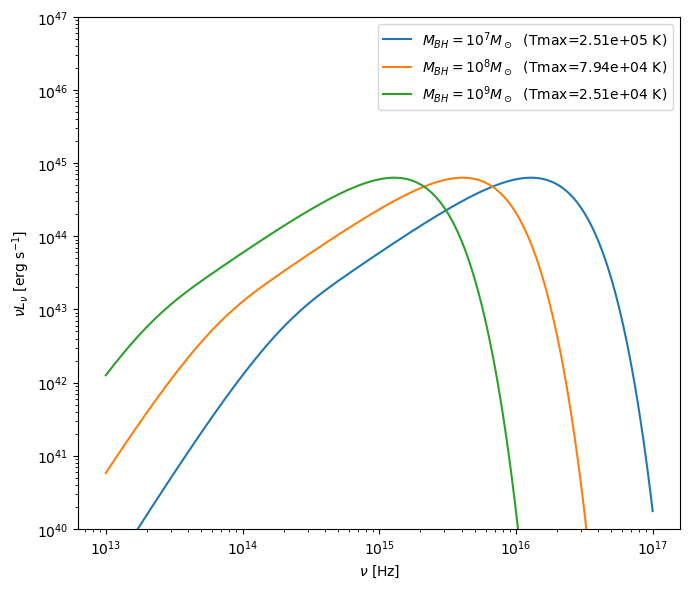

M_BH = 1.0e+07 Msun: nu_peak*L(nu_peak) = 6.315e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s
M_BH = 1.0e+08 Msun: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s
M_BH = 1.0e+09 Msun: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk_ref = 6.500e+44 erg/s


In [9]:
MBH_ref_msun = 1e8
MBH_ref = MBH_ref_msun * Msun
Ledd_ref = 1.3e38 * (MBH_ref / Msun)
Ldisk_ref = 0.1 * Ledd_ref
Mdot_ref = Ldisk_ref / (eta * c**2)

print(f"Mdot_ref, computed for 1e8 Msun = {Mdot_ref:.3e} g/s")


def disk_nuLnu_fixed_mdot(MBH_msun, nu, Mdot_fixed, Nr=2000):

    MBH = MBH_msun * Msun
    # Radii
    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)
    # Temperature profile with fixed Mdot
    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot_fixed) / (8 * np.pi * sigma * R**3) * f)**0.25

    # Compute B_nu(nu, T) for each frequency and temperature
    Nnu = len(nu)
    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)
    # Compute L(nu) by integrating over R
    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu

    return nu * Lnu, T.max()


# Comparison between three different masses at fixed Mdot
masses = [1e7, 1e8, 1e9]
plt.figure(figsize=(7, 6))
for M in masses:
    nuLnu_mass, Tmax = disk_nuLnu_fixed_mdot(M, nu, Mdot_ref, Nr=Nr)

    plt.loglog(
        nu,
        nuLnu_mass,
        label=fr'$M_{{BH}}=10^{int(np.log10(M))} M_\odot$  (Tmax={Tmax:.2e} K)'
    )
plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
#plt.title(r'SS Disk: Comparison of Black Hole Masses at Fixed $\dot{M}$')
plt.ylim(1e40, 1e47)
# The limits are chosen to better highlight the differences between the curves,
# especially at high frequencies, where the peak shift toward lower frequencies
# becomes clearer as the black hole mass increases.

plt.legend()
plt.tight_layout()
plt.show()

# Compute nu_peak*L(nu_peak) for each mass and compare it with 0.5*Ldisk_ref
for M in masses:
    nuLnu_mass, Tmax = disk_nuLnu_fixed_mdot(M, nu, Mdot_ref, Nr=Nr)
    i_peak = np.argmax(nuLnu_mass)
    nu_peak = nu[i_peak]
    Lnu_peak = nuLnu_mass[i_peak] / nu_peak
    nuLnu_peak = nu_peak * Lnu_peak
    print(
        f"M_BH = {M:.1e} Msun: "
        f"nu_peak*L(nu_peak) = {nuLnu_peak:.3e} erg/s, "
        f"0.5*Ldisk_ref = {0.5 * Ldisk_ref:.3e} erg/s"
    )

FOURTH TEST:  
I vary the disk luminosity in order to see how the spectrum changes with Ldisk,while keeping the black hole mass fixed at 10^8 Msun. Therefore, Mdot varies.  
If Ldisk increases, Mdot also increases, and the disk temperature increases approximately as Tmax ∝ Mdot^(1/4).  
As the disk temperature increases, the spectral peak shifts toward higher frequencies. In addition, the value of nu*L(nu) at the peak also increases with Ldisk.

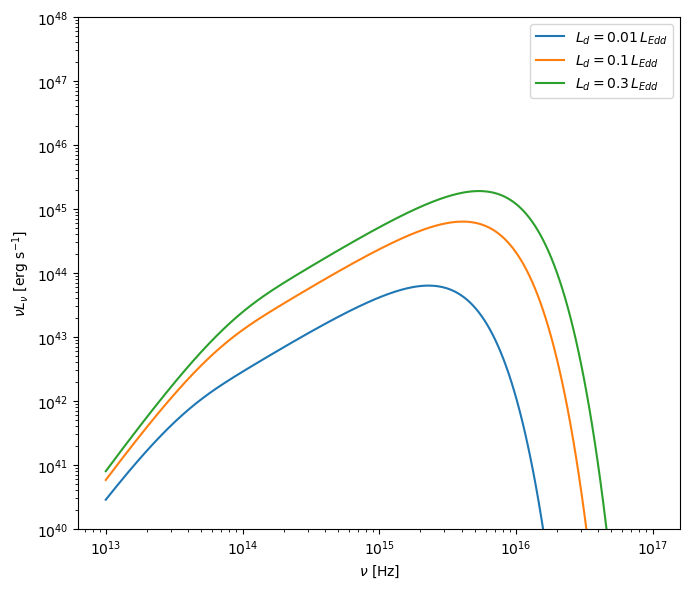

Ldisk = 1.300e+44 erg/s: nu_peak*L(nu_peak) = 6.314e+43 erg/s, 0.5*Ldisk = 6.500e+43 erg/s
Ldisk = 1.300e+45 erg/s: nu_peak*L(nu_peak) = 6.314e+44 erg/s, 0.5*Ldisk = 6.500e+44 erg/s
Ldisk = 3.900e+45 erg/s: nu_peak*L(nu_peak) = 1.894e+45 erg/s, 0.5*Ldisk = 1.950e+45 erg/s


In [10]:
Ledd = 1.3e38 * (MBH / Msun)  # erg/s
f_list = [0.01, 0.1, 0.3]  # Ldisk = f * Ledd

def nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin):

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25
    # Compute Bnu using a loop
    Nnu = len(nu)
    Nr = len(R)
    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    I_nu = np.trapezoid(R[None, :] * Bnu, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    return nu * Lnu

plt.figure(figsize=(7, 6))

# Compute nu*L(nu) for each luminosity factor and plot the curves together
for fEdd in f_list:
    Ldisk = fEdd * Ledd
    Mdot = Ldisk / (eta * c**2)
    nuLnu_lum = nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin)

    plt.loglog(
        nu,
        nuLnu_lum,
        label=fr'$L_d={fEdd:g}\,L_{{Edd}}$')
plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
plt.ylim(1e40, 1e48)
#plt.title(r'SS Disk ($M_{BH}=10^8 M_\odot$): Dependence on $L_d$')
plt.legend()
plt.tight_layout()
plt.show()

# Compute nu_peak*L(nu_peak) for each luminosity and compare it with 0.5*Ldisk
for fEdd in f_list:
    Ldisk = fEdd * Ledd
    Mdot = Ldisk / (eta * c**2)
    nuLnu_lum = nuLnu_disk_for_Mdot(MBH, R, nu, Mdot, Rin)
    i_peak = np.argmax(nuLnu_lum)
    nu_peak = nu[i_peak]
    Lnu_peak = nuLnu_lum[i_peak] / nu_peak
    nuLnu_peak = nu_peak * Lnu_peak
    print(
        f"Ldisk = {Ldisk:.3e} erg/s: "
        f"nu_peak*L(nu_peak) = {nuLnu_peak:.3e} erg/s, "
        f"0.5*Ldisk = {0.5 * Ldisk:.3e} erg/s")

# Part II — Computing the Ionizing Luminosities  
In the second part of the program, I use a file containing ionization energies and the corresponding ionization frequencies. Starting from the disk-emission curve computed in the first part, I calculate the ionizing luminosity associated with each ionization threshold.  
For each ionization frequency I compute Lion.  
Then I plot the disk-emission curve together with the ionization thresholds in an Lnu versus nu diagram.

In [11]:
nu_max = 1e17  # Hz
# Read the data file
data = np.genfromtxt("dati.asc", dtype=None, encoding="utf-8")
names, Eion, nu_ion_list = np.genfromtxt(
    "dati.asc",
    dtype=("U20", float, float),
    unpack=True)

# The data file has shape (N, 3).
# Data type for each column:
# string of maximum length 20 for the names,
# float for Eion,
# float for nu_ion_list.

In [12]:
# Compute L_ion for each transition as the integral of L(nu)
# from nu_ion to nu_max
Lion_list = []
for nu_ion in nu_ion_list:
    # If nu_ion is above nu_max, there is no contribution in the selected range
    if nu_ion >= nu_max:
        Lion = 0.0
    else:
        mask = (nu >= nu_ion) & (nu <= nu_max)
        Lion = np.trapezoid(Lnu[mask], nu[mask])  # erg/s

    Lion_list.append(Lion)

Lion_list = np.array(Lion_list)

# Print a table with the results
print("Transition   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] ")
for n, E, nui, Li in zip(names, Eion, nu_ion_list, Lion_list):
    print(f"{n:>12}  {E:10.3g}  {nui:12.3e}  {Li:12.3e}")

# NB: Higher ionization frequencies sample a smaller portion of the disk spectrum.

Transition   |   E_ion  |  nu_ion [Hz] |  L_ion [erg/s] 
          Ha        1.89     4.600e+14     1.231e+45
          Hb        2.55     6.200e+14     1.196e+45
          Hg        2.86     6.910e+14     1.180e+45
          Hd        3.02     7.370e+14     1.168e+45
        MgII          15     3.630e+15     5.393e+44
        CIII        24.4     5.890e+15     2.448e+44
         CIV        47.9     1.158e+16     2.321e+43


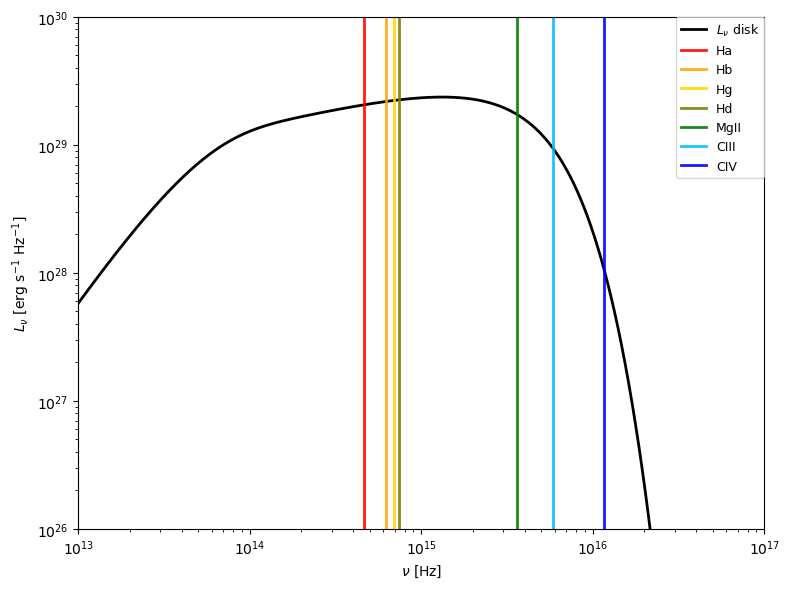

In [13]:
# Plot the disk spectrum with the ionization thresholds highlighted

plt.figure(figsize=(8, 6))

# Disk curve
plt.loglog(
    nu,
    Lnu,
    lw=2,
    color="k",
    label=r"$L_\nu$ disk"
)

# Colori fissati per le linee
colori_ion = {
    "Ha": "red",
    "Hb": "orange",
    "Hg": "gold",
    "Hd": "olive",
    "MgII": "green",
    "CIII": "deepskyblue",
    "CIV": "blue"
}

for n, nui in zip(names, nu_ion_list):

    plt.axvline(
        nui,
        ls="-",
        lw=2,
        alpha=0.9,
        color=colori_ion.get(n, "gray"),  # grigio se la linea non è nel dizionario
        label=n
    )

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]')

plt.xlim(1e13, 1e17)
plt.ylim(1e26, 1e30)

# legenda
plt.legend(
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()

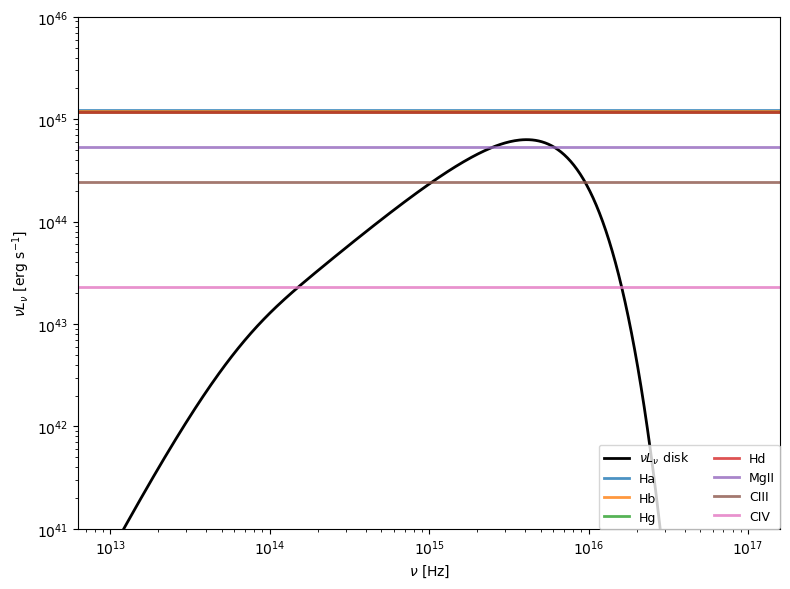

In [14]:
# Plot the disk spectrum with the ionization thresholds highlighted,
# now using nu*L(nu), which makes the comparison with L_ion clearer.

plt.figure(figsize=(8, 6))

# Disk curve
plt.loglog(nu, nu * Lnu, lw=2, color="k", label=r'$\nu L_\nu$ disk')
# plt.plot(nu, nu * Lnu, lw=2, color="k", label=r'$\nu L_\nu$ disk')  # Linear scale

# Distinct colors
cmap = plt.get_cmap("tab10")
colors = [cmap(i % cmap.N) for i in range(len(names))]

# Lines for each transition, using the same color for the corresponding horizontal line
for n, nui, Li, col in zip(names, nu_ion_list, Lion_list, colors):
    # plt.axvline(nui, ls="--", lw=2, alpha=0.9, color=col)
    plt.axhline(
        Li,
        ls="-",
        lw=2,
        alpha=0.8,
        color=col,
        label=str(n))

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]')
plt.ylim(1e41, 1e46)
#plt.title(r'Disk: Ionization Luminosities')

plt.legend(
    fontsize=9,
    title_fontsize=10,
    #in basso a destra
    loc="lower right",   
    ncols=2,  
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()